# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 3: De aprendizaje supervisado, o no supervisado, o ambos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Objetivos** : caracterizar los puntos de muestreo en base a la abundancia y las características de los
ejemplares colectados para responder las demandas de la municipalidad.
1. Caracterizar los puntos de muestreo considerando los ejemplares pescados. Se debe
considerar la variabilidad temporal.
2. Agrupar los puntos de muestreo mediante técnicas de análisis no supervisado.
3. Describir la variabilidad temporal.
4. Redactar una recomendación para el gobierno local que tenga por objetivo la subsistencia del
recurso pesquero a lo largo del tiempo.

In [34]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

from scipy import stats

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

In [35]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [36]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [37]:
# Estandarizacion previa - nombres de columnas
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(10)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
2,ene_96,3,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,74.6,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
3,ene_96,4,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,3.0,NaN,75.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ene_96,5,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,75.6,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
5,ene_96,6,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,4.0,3,77.6,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
6,ene_96,7,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,76.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
7,ene_96,8,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,69.9,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
8,ene_96,9,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,80.7,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
9,ene_96,10,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,67.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN


### Informacion acerca de las variables

Datos genrales de las campañas:

- enero_96 > Muestreo a bordo de Wapisa, 26/01/96; WAPJAN96
- abril_96 > Muestreo a bordo de Catamarca 2/4/96
- julio_96 > Muestreo a bordo de Wapisa y Catamarca, 24 y 25.07.96; LANJUL96.WQ1
- octubre_96 > Muestreo a bordo de Catamarca, 2 y 3.10.96; CATOCT96.WQ1
- octubre_97 > Muestreo a bordo de la Catamarca el 6 y 7 de octubre de 1997
- octubre_98 > Muestreo a bordo de la Catamarca el 13 de octubre de 1998

Datos adicionales:

- julio_97

La codificación de las variables categóricas se reconstruyó a partir del protocolo de muestreo
(Lovrich, *Lithodes - Muestreo*) que documenta el criterio de toma de datos en el campo.

| Variable | Descripción | Códigos / Unidades |
|---|---|---|
| `fecha` | Temporada de muestreo | ene_96, abril_96, jul_96, oct_96, jul_97, oct_97, oct_98 |
| `rk` | Número de registro/individuo dentro de la temporada | entero |
| `tipo` | Tipo de captura y cantidad de trampas (o desembarque) del punto de muestreo | texto, p.ej. "Captura total de 3 trampas" |
| `localizacion` | Punto de referencia geográfico del muestreo | texto libre |
| `latitud`, `longitud` | Coordenadas del punto de muestreo | grados decimales |
| `profundidad` | Profundidad del punto de muestreo | metros |
| `especie` | Especie del individuo | 1 = centolla (*Lithodes santolla*), 2 = centollón (*Paralomis granulosa*) |
| `sexo` | Sexo del individuo | 1 = macho, 2 = hembra* |
| `estado_caparazon` | Estado del caparazón / epibiosis | 1 postmuda, 2 duro sin epibiontes, 3 duro con epibiontes (Spirorbis), 4 duro con epibiontes (Balanus), 5 duro con 2º caparazón visible, 6 exuvia, 30 entre estado 2 y 3 |
| `cirripedio` | Presencia/nivel de cirripedios (parásito *Briarosaccus*) | 1–3 (nivel), sufijo "p" en algunos registros |
| `largo_caparazon` | Largo del caparazón (LC) | mm |
| `ancho_caparazon` | Ancho del caparazón | mm |
| `largo_quela` | Largo de la pinza derecha | mm |
| `ancho_quela` | Ancho de la pinza derecha | mm |
| `huevos` | Estado de desarrollo de los huevos (solo hembras) | 0 sin huevos, 1 huevos sin ojos, 2 huevos sin ojos con mancha blanca, 3 huevos con ojos, 4 eclosionando, 5 cápsulas vacías (postovígera), 6 embriogénesis heterogénea, 7 trazas |
| `parasito` | Presencia de parásito *Pseudione* | 2 isopodo presente, 20 isopodo cicatriz, 3 rizocefalo presente, 30 rizocefalo cicatriz |
| `observaciones` | Notas de campo | texto libre |


## 1. Limpieza inicial del dataset  
Se eliminan las columnas `unnamed: 18` y `unnamed: 19` ya que no aportan información.

In [38]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,087 | Columnas: 18


In [39]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_raw.dropna(subset=['latitud', 'longitud', 'localizacion'],how='all',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 9,105 | Columnas: 18


In [40]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas vinculando explícitamente la cantidad
    con los términos 'trampa' o 'linea'.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    # 1. Patrón con número ANTES del término (ej: "10 trampas", "captura de 2 líneas")
    match_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)

    # 2. Patrón con número DESPUÉS del término (ej: "trampas: 10", "línea 2")
    match_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)

    if match_antes:
        numero = float(match_antes.group(1))
        unidad = match_antes.group(2)
    elif match_despues:
        unidad = match_despues.group(1)
        numero = float(match_despues.group(2))
    else:
        # Casos como "Captura total trampas wp 149" (sin cantidad especificada) o muestreos
        return np.nan

    # 3. Conversión de unidades (1 línea = 10 trampas)
    if 'linea' in unidad or 'línea' in unidad:
        return numero * 10.0
    return numero

In [41]:
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos del cálculo de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 8865 (97.4%)
 Registros excluidos del cálculo de IAR (índice de abundancia relativa): 240 (2.6%)

Categorías excluidas (sin equivalente en trampas):
tipo
Captura total trampas wp 149    110
Captura por la Wapisa            75
Muestreo de cubierta 3           55
Name: count, dtype: int64


#  Segmentación de individuos 

**Objetivo:** segmentar los individuos capturados según su perfil biológico, para identificar grupos naturales de ejemplares con características similares, y relacionar esos grupos con el sector del canal (Este/Oeste de Paso Mackinlay) y la temporada.

**Decisiones de diseño:**
- Se trabaja solo con **centollón**, que es el 97% de los registros.
- `sector_canal` y `fecha` **no entran** como variables del clustering. Se usan después para interpretar los grupos.

> **Corrección respecto a la celda anterior de `sector_canal`:** `np.where(longitud <= x, 'Oeste', 'Este')` asigna `'Este'` a todos los registros sin longitud (NaN). Había 1.134 individuos (9 localizaciones sin coordenadas) mal clasificados. Ahora quedan como `'Sin dato'` y se excluyen del cruce con el sector.

## 2.1 Preparación de datos

### Faltantes por variable y criterio de tratamiento


In [29]:
!pip install gower prince kmodes --quiet

In [44]:
import warnings
import gower
import prince
from kmodes.kprototypes import KPrototypes
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cophenet
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, adjusted_rand_score

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

faltantes = (df_raw[columnas_numericas + columnas_categoricas + ['sector_canal']].isna().mean() * 100).round(1)

decision = {
    'ancho_caparazon': 'Descartar variable (>95% faltante)',
    'largo_quela': 'Descartar variable (>95% faltante)',
    'ancho_quela': 'Descartar variable (>95% faltante)',
    'parasito': 'Descartar del clustering (>95% faltante); se usa solo como descriptor',
    'cirripedio': 'NaN = sin cirripedio -> nivel 0; entra como categórica (0-3)',
    'huevos': 'Estadio 0-7; NaN en machos = no aplica -> 0; entra como categórica; hembras sin dato: se descartan',
    'latitud': 'No es variable del clustering; se imputa por localización solo para sector_canal',
    'longitud': 'No es variable del clustering; se imputa por localización solo para sector_canal',
    'num_trampas': 'Descartar filas (esfuerzo no estimable); no es variable del clustering, solo del índice de riesgo',
    'profundidad': 'Imputar mediana por localización',
    'estado_caparazon': 'Descartar filas (2 registros)',
    'largo_caparazon': 'Completa',
    'especie': 'Se conserva solo centollón (97% de los registros); no es variable del clustering',
    'sexo': 'Completa',
    'fecha': 'Completa; solo para interpretar',
    'sector_canal': "Completa ('Sin dato' si la localización no tiene coordenadas)",
    'localizacion': 'Identificador; solo para interpretar',
    'tipo': 'Identificador del evento; no se usa',
    'observaciones': 'Texto libre; no se usa',
}
tabla_faltantes = pd.DataFrame({'% faltante': faltantes, 'tratamiento': pd.Series(decision)})
tabla_faltantes.sort_values('% faltante', ascending=False)


,% faltante,tratamiento
ancho_caparazon,99.0,Descartar variable (>95% faltante)
ancho_quela,98.8,Descartar variable (>95% faltante)
largo_quela,98.8,Descartar variable (>95% faltante)
observaciones,98.6,Texto libre; no se usa
parasito,97.3,Descartar del clustering (>95% faltante); se usa solo como descriptor
cirripedio,86.2,NaN = sin cirripedio -> nivel 0; entra como categórica (0-3)
huevos,62.5,Estadio 0-7; NaN en machos = no aplica -> 0; entra como categórica; hembras sin dato: se descartan
latitud,12.7,No es variable del clustering; se imputa por localización solo para sector_canal
longitud,12.7,No es variable del clustering; se imputa por localización solo para sector_canal
num_trampas,2.6,"Descartar filas (esfuerzo no estimable); no es variable del clustering, solo del índice de riesgo"


### Alcance y tratamiento de las variables

- **Solo centollón** (*Paralomis granulosa*): es el 97% de los registros (8.861 de 9.105). Las 244 centollas se excluyen; con tan pocos individuos y otra biología (talla, esfuerzo) formarían clusters propios que no aportan al análisis de la especie principal.
- `huevos` (estadio 0-7) y `cirripedio` (nivel 0-3) entran como **categóricas**: cada estadio/nivel es una modalidad y la distancia de Gower solo distingue "igual / distinto". Se pierde el orden, pero se evita suponer que los estadios están equiespaciados (el 5 es "cápsulas vacías" y el 6-7 "heterogénea / trazas", que no continúan la secuencia de desarrollo 1-4).
- Los **machos** no portan huevos: `huevos_ord = 0` (no aplica). El sexo ya los distingue de las hembras sin huevos.
- Códigos fuera del protocolo: `30` y `40` aparecen concentrados en una sola campaña (oct_97) y se interpretan como `3` y `4` (artefacto de tipeo); `conojos` = 3; `po` (postovígera) = 5; `7 en 1` es ambiguo y se descarta.
- `cirripedio` se reduce a su nivel 0-3 (se descartan sufijos "p" y decimales) y los NaN se interpretan como ausencia.
- `estado_caparazon` es nominal: se agrupa en `reciente` (1 postmuda, 5 segundo caparazón, 6 exuvia; muy pocos casos), `duro_limpio` (2 y 30), `spirorbis` (3) y `balanus` (4).
- `largo_caparazon < 30 mm` (1 registro, 8,1 mm) es un error de carga evidente y se descarta.
- `num_trampas` **no entra al clustering** (es una característica del evento de pesca, no del ejemplar), pero se conserva para el índice de riesgo.


In [45]:
df_ind = df_raw.copy()
n_inicial = len(df_ind)

# Error de carga evidente
df_ind = df_ind[df_ind['largo_caparazon'] >= 30].copy()

# Solo centollón: es el 97% de los registros
df_ind['especie'] = df_ind['especie'].map({1: 'centolla', 2: 'centollon'})
print('Centollas excluidas:', (df_ind['especie'] == 'centolla').sum())
df_ind = df_ind[df_ind['especie'] == 'centollon'].copy()

# huevos: estadio 0-7
MAPA_HUEVOS = {'0': 0, '1': 1, '2': 2, '3': 3, '30': 3, 'conojos': 3, '4': 4, '40': 4,
               '5': 5, 'po': 5, '6': 6, '7': 7}
h = df_ind['huevos'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
df_ind['huevos_ord'] = h.map(MAPA_HUEVOS)
df_ind.loc[df_ind['sexo'] == 1, 'huevos_ord'] = 0   # machos: no aplica

# cirripedio: nivel 0-3, NaN = ausente
df_ind['cirripedio_nivel'] = (df_ind['cirripedio'].astype(str).str.extract(r'(\d)')[0]
                              .astype(float).fillna(0).astype(int))
df_ind['parasito_presente'] = df_ind['parasito'].notna().astype(int)

# estado del caparazón agrupado (nominal)
MAPA_ESTADO = {1: 'reciente', 5: 'reciente', 6: 'reciente', 2: 'duro_limpio', 30: 'duro_limpio',
               3: 'spirorbis', 4: 'balanus'}
df_ind['estado'] = df_ind['estado_caparazon'].map(MAPA_ESTADO)

# profundidad: mediana por localización, luego global
df_ind['profundidad'] = df_ind['profundidad'].fillna(df_ind.groupby('localizacion')['profundidad'].transform('median'))
df_ind['profundidad'] = df_ind['profundidad'].fillna(df_ind['profundidad'].median())

df_ind['sexo'] = df_ind['sexo'].map({1: 'macho', 2: 'hembra'})

# Descarte listwise de lo que no se puede imputar
requeridas = ['estado', 'huevos_ord', 'num_trampas']
print('Filas descartadas por faltantes:', df_ind[requeridas].isna().any(axis=1).sum())
df_ind = df_ind.dropna(subset=requeridas).reset_index(drop=True)
df_ind['huevos_ord'] = df_ind['huevos_ord'].astype(int)

print(f'Filas: {n_inicial:,} -> {len(df_ind):,} ({len(df_ind)/n_inicial*100:.1f}% conservado)')
print(df_ind['huevos_ord'].value_counts().sort_index().to_dict())
print(df_ind['estado'].value_counts().to_dict())


Centollas excluidas: 244
Filas descartadas por faltantes: 237
Filas: 9,105 -> 8,623 (94.7% conservado)
{0: 6064, 1: 1285, 2: 1, 3: 762, 4: 49, 5: 261, 6: 97, 7: 104}
{'spirorbis': 7265, 'balanus': 1143, 'duro_limpio': 209, 'reciente': 6}


## 2.2 Codificación mixta: distancia de Gower

Variables del clustering :

| Tipo | Variables |
|---|---|
| Numéricas continuas | `largo_caparazon`, `profundidad` |
| Categóricas | `sexo`, `estado` (caparazón), `huevos_ord` (estadio 0-7), `cirripedio_nivel` (0-3) |

Gower calcula, por variable, una disimilitud en [0, 1] (diferencia normalizada por el rango en numéricas; 0/1 en categóricas) y promedia. No requiere one-hot ni escalado manual. Con n ≈ 8.600 la matriz completa ocupa ~300 MB en `float32`, un tamaño manejable, así que se calcula completa y K-Prototypes se usa como contraste escalable.

Todas las variables pesan igual: 2 de 6 son continuas y 4 de 6 categóricas, por lo que la parte categórica domina la distancia. `sexo` y `huevos_ord` están relacionadas (los machos son siempre 0), lo que da algo más de peso a la dimensión reproductiva; se asume como aceptable porque es justamente el eje de interés para la conservación.


In [46]:
VARS_NUM = ['largo_caparazon', 'profundidad']
VARS_ORD = []  # chequear aca bien pero el algortimos puede usar variables ordinales...osea creo que es como niveles o jerar
VARS_CAT = ['sexo', 'estado', 'huevos_ord', 'cirripedio_nivel']
VARS_CLUSTER = VARS_NUM + VARS_ORD + VARS_CAT

X = df_ind[VARS_CLUSTER].copy()
X[VARS_NUM + VARS_ORD] = X[VARS_NUM + VARS_ORD].astype(float)
X[VARS_CAT] = X[VARS_CAT].astype(str)
mascara_cat = np.array([c in VARS_CAT for c in VARS_CLUSTER])

D = gower.gower_matrix(X, cat_features=mascara_cat)
print(D.shape, D.dtype, f'{D.nbytes/1e6:.0f} MB')
print('Distancia media:', D.mean().round(3), '| máx:', D.max().round(3))


(8623, 8623) float32 297 MB
Distancia media: 0.311 | máx: 0.946


## 2.3 Reducción de dimensionalidad: FAMD

PCA solo acepta variables numéricas. FAMD (Factor Analysis of Mixed Data) combina PCA para las numéricas y MCA para las categóricas, estandarizando ambas para que pesen de forma comparable. Se usa para **explorar la estructura** de los datos y para **visualizar** los clusters en 2D; el clustering en sí se hace sobre Gower.

F1    15.2
F2    12.2
F3     7.3
F4     6.9
F5     6.7
F6     6.4
Acumulada 2 primeros ejes: 27.4 %


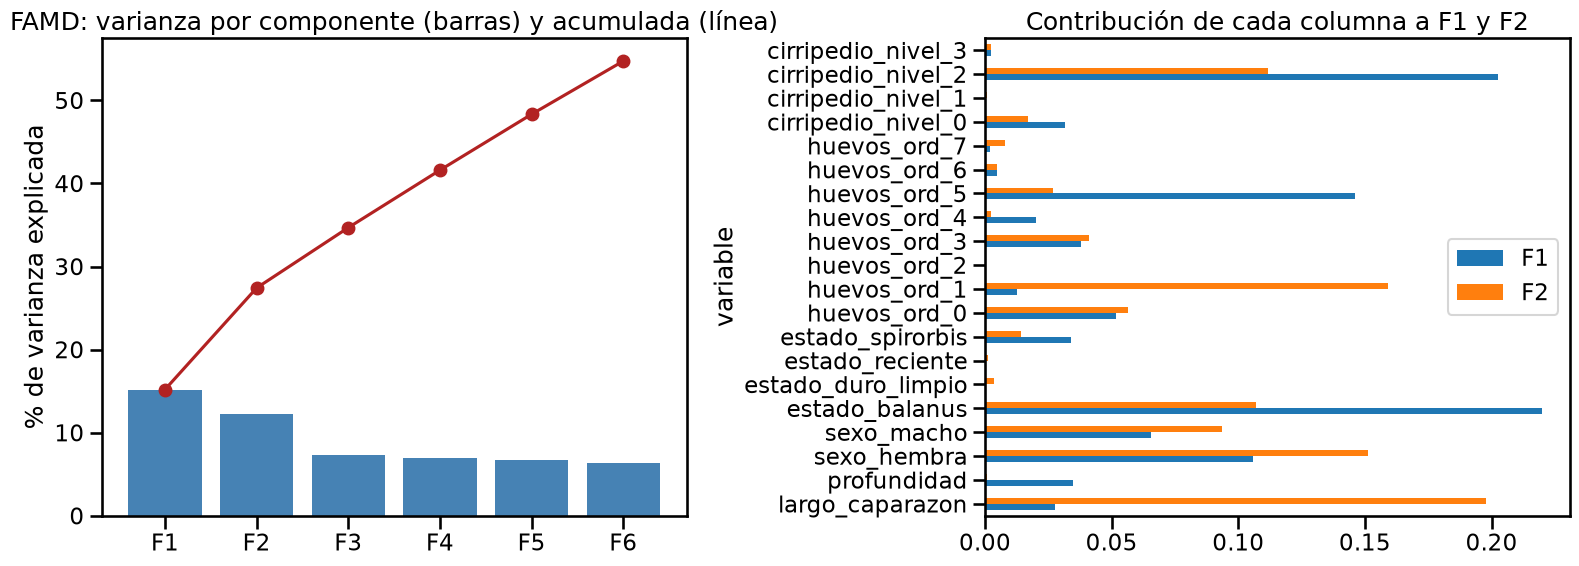

In [47]:
X_famd = X.copy()
X_famd[VARS_CAT] = X_famd[VARS_CAT].astype('category')

famd = prince.FAMD(n_components=6, n_iter=5, random_state=RANDOM_STATE, engine='sklearn')
famd = famd.fit(X_famd)
coords = famd.row_coordinates(X_famd)   # Bien aca supuestamente despues de armar los nuevos ejes los Fs , cada registro que tengo va a tener componentes de esos Fs 
coords.columns = [f'F{i+1}' for i in range(coords.shape[1])]

inercia = pd.Series(famd.eigenvalues_summary['% of variance'].astype(str).str.rstrip('%').astype(float).values,
                    index=coords.columns)
print(inercia.round(1).to_string())
print('Acumulada 2 primeros ejes:', inercia.iloc[:2].sum().round(1), '%')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].bar(inercia.index, inercia.values, color='steelblue')
ax[0].plot(inercia.index, inercia.cumsum().values, 'o-', color='firebrick')
ax[0].set_ylabel('% de varianza explicada')
ax[0].set_title('FAMD: varianza por componente (barras) y acumulada (línea)')

# Proporción de la inercia de cada eje aportada por cada variable / modalidad
contrib = famd.column_contributions_.iloc[:, :2]
contrib.columns = ['F1', 'F2']
contrib.plot.barh(ax=ax[1])
ax[1].set_title('Contribución de cada columna a F1 y F2')
plt.tight_layout()
plt.show()

## 2.4 Clustering

### 2.4.1 Jerárquico sobre la matriz de Gower

Ward exige distancias euclídeas, así que con Gower se usan enlaces `average` y `complete`. Se comparan por correlación cofenética (qué tan bien el dendrograma conserva las distancias originales) y por silueta para k = 2…10, sin fijar k a priori.

In [50]:
D_cond = squareform(D, checks=False).astype(np.float64)    # Aca no entiendo bien porque tengo que hacer la conversion a formato condensado

enlaces = {}
resumen = []
for metodo in ['average', 'complete']:
    Z = linkage(D_cond, method=metodo)    # Aca va el cluster jerarquico
    coph = cophenet(Z, D_cond)[0]
    enlaces[metodo] = Z
    for k in range(2, 11):
        etiquetas = fcluster(Z, k, criterion='maxclust')
        tam = np.bincount(etiquetas)[1:]
        resumen.append({'enlace': metodo, 'k': k, 'silueta': silhouette_score(D, etiquetas, metric='precomputed'),
                        'cofenetica': coph, 'tam_min_%': tam.min() / len(etiquetas) * 100})

df_jer = pd.DataFrame(resumen)
print('Correlación cofenética:', df_jer.groupby('enlace')['cofenetica'].first().round(3).to_dict())  

## Aca la correccion esta supeustamente me deberia revisar o chequear las relaciones de distancias originales en el dendograma
## Basicamente de ahi puedo sacar si el arbol que se construaya va a representar o conservrr esas relaciones originales
## que va del 0 a 1 en donde 1 es buena correlacion

## Por otro lado la silieta en este caso es una referencuia para ver que tan seperadao esta cada individuo con respecto a su cluster  

# Con enlace 'average' aparecen clusters de 2-7 individuos que inflan la silueta; se exige que el menor cluster tenga >= 0,25% de los individuos (~20)
#Podrías justificarlo, por ejemplo, por el interés en evitar clusters residuales extremadamente pequeños que dificulten su interpretación biológica/ecológica.
df_jer['valido'] = df_jer['tam_min_%'] >= 0.25
display(df_jer.drop(columns='cofenetica').round(3).set_index(['enlace', 'k']))

mejor = df_jer[df_jer['valido']].sort_values('silueta', ascending=False).iloc[0]
print(f"Mejor silueta entre particiones válidas: enlace={mejor['enlace']}, k={int(mejor['k'])}, silueta={mejor['silueta']:.3f}")


Correlación cofenética: {'average': 0.896, 'complete': 0.806}


silueta  tam_min_%  valido
enlace   k                             
average  2     0.561      7.120    True
         3     0.609      7.120    True
         4     0.597      0.081   False
         5     0.647      0.081   False
         6     0.636      0.081   False
         7     0.626      0.081   False
         8     0.626      0.081   False
         9     0.623      0.023   False
         10    0.617      0.023   False
complete 2     0.582     38.258    True
         3     0.611      7.097    True
         4     0.580      0.777    True
         5     0.572      0.267    True
         6     0.629      0.267    True
         7     0.594      0.267    True
         8     0.596      0.267    True
         9     0.595      0.267    True
         10    0.599      0.267    True

Mejor silueta entre particiones válidas: enlace=complete, k=6, silueta=0.629


El enlace average presentó una mayor correlación cofenética (0.896 frente a 0.806), indicando una mejor preservación de las distancias Gower en el dendrograma. Sin embargo, al evaluar la calidad de las particiones mediante la silueta y exigir que ningún cluster contenga menos del 0.25% de los individuos, el mejor resultado correspondió al enlace complete con k=6, con una silueta de 0.629. El enlace average alcanzó siluetas superiores para k≥4, pero dichas soluciones generaron clusters extremadamente pequeños, por lo que fueron descartadas.

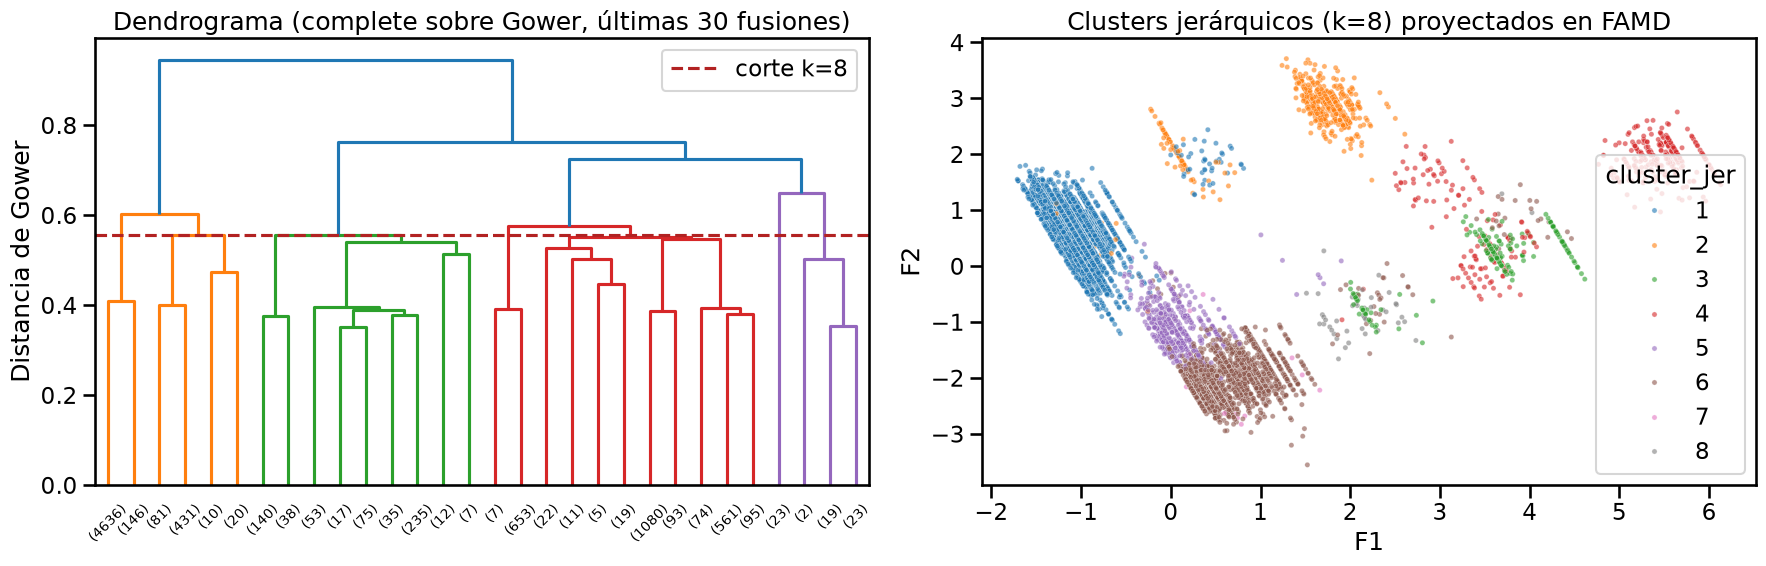

{1: 4782, 2: 542, 3: 178, 4: 434, 5: 660, 6: 1960, 7: 23, 8: 44}


In [51]:
# La silueta es casi plana entre k=3 y k=10 (0,57-0,63) porque las categóricas dominan Gower(es realmente asi ??). Se fija k=8, 
# el menor k en que las hembras sin huevos (LC ~64 mm) se separan de las ovígeras y los machos infectados de los sanos.

## Chequeat caso k=6 que es el que habia tenia mejor silueta...agrego a 8 solo poruqe creo que si tieen relevancia los demas cluesters
## k=8 fue seleccionado como compromiso entre calidad estadística e interpretabilidad biológica.

ENLACE_JER = 'complete'
K_JER = 8
Z = enlaces[ENLACE_JER]
df_ind['cluster_jer'] = fcluster(Z, K_JER, criterion='maxclust')

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True, no_labels=False, ax=ax[0])
corte = Z[-(K_JER - 1), 2]
ax[0].axhline(corte, color='firebrick', ls='--', label=f'corte k={K_JER}')
ax[0].set_title(f"Dendrograma ({ENLACE_JER} sobre Gower, últimas 30 fusiones)")
ax[0].set_ylabel('Distancia de Gower')
ax[0].legend()

sns.scatterplot(x=coords['F1'], y=coords['F2'], hue=df_ind['cluster_jer'], palette='tab10', s=14, alpha=0.6, ax=ax[1])
ax[1].set_title(f'Clusters jerárquicos (k={K_JER}) proyectados en FAMD')
plt.tight_layout()
plt.show()

print(df_ind['cluster_jer'].value_counts().sort_index().to_dict())


### 2.4.2 K-Prototypes (k fijo) y comparación

K-Prototypes combina distancia euclídea (numéricas estandarizadas) y desajuste simple (categóricas) en un esquema tipo k-means. Escala linealmente con n y no necesita la matriz de distancias, por lo que es la opción para volúmenes mayores. Aquí se corre sobre los mismos individuos y se evalúa k = 2…10 con el costo (codo) y la silueta medida sobre la **misma** matriz de Gower, para que sea comparable con el jerárquico. La concordancia entre ambas particiones se mide con el Índice de Rand Ajustado (ARI).

,costo,silueta_gower,tam_min_%,ARI_vs_jerarquico
k,,,,
2,15226.970,0.173,49.136,0.095
3,10913.206,0.076,22.312,0.067
4,9305.846,0.011,21.361,0.120
5,8017.907,0.056,11.956,0.134
6,7816.339,0.064,12.606,0.183
7,6600.676,0.089,11.284,0.183
8,6241.439,0.034,8.164,0.195
9,5812.650,0.046,3.514,0.199
10,5393.895,0.010,3.467,0.162


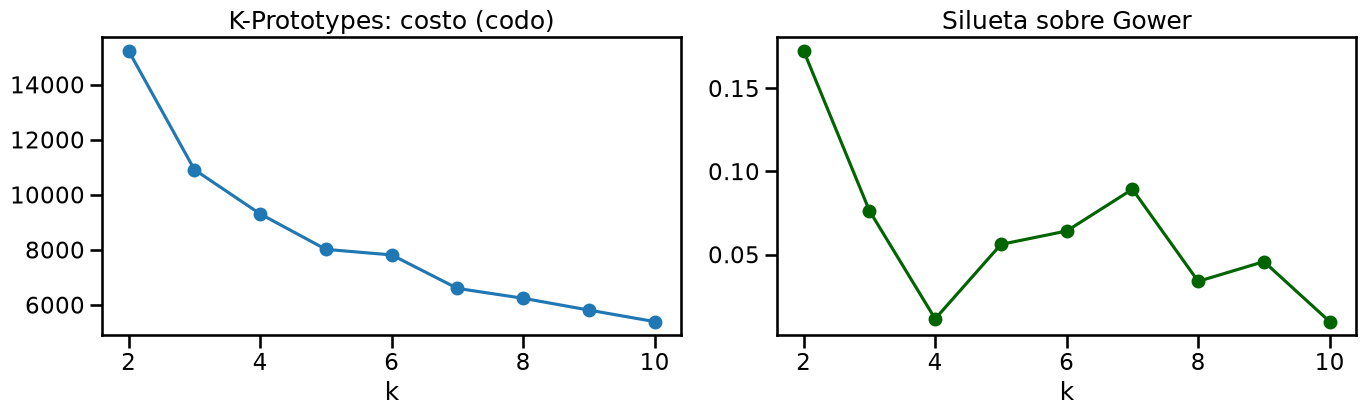

In [52]:
from sklearn.preprocessing import StandardScaler

cols_kp = VARS_NUM + VARS_ORD + VARS_CAT
X_kp = X[cols_kp].copy()
X_kp[VARS_NUM + VARS_ORD] = StandardScaler().fit_transform(X_kp[VARS_NUM + VARS_ORD])  ## Le hago un scaler para las diferencias de las medidas 
X_kp[VARS_CAT] = X_kp[VARS_CAT].astype(str)
X_kp_arr = X_kp.to_numpy(dtype=object)
idx_cat = list(range(len(VARS_NUM + VARS_ORD), len(cols_kp)))

res_kp, modelos_kp = [], {}
for k in range(2, 11):
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=1, random_state=RANDOM_STATE, n_jobs=1)
    etiquetas = kp.fit_predict(X_kp_arr, categorical=idx_cat)
    modelos_kp[k] = etiquetas
    tam = np.bincount(etiquetas)
    res_kp.append({'k': k, 'costo': kp.cost_, 'silueta_gower': silhouette_score(D, etiquetas, metric='precomputed'),
                   'tam_min_%': tam.min() / len(etiquetas) * 100,
                   'ARI_vs_jerarquico': adjusted_rand_score(df_ind['cluster_jer'], etiquetas)})  ## para comparar las dos particules pero comparo la jerarquica con 8 con los demas de estos casos 

df_kp = pd.DataFrame(res_kp).set_index('k')
display(df_kp.round(3))

## qu3 tan buenos son estos clusters según la misma nocion de similitud Gower

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(df_kp.index, df_kp['costo'], 'o-'); ax[0].set_title('K-Prototypes: costo (codo)'); ax[0].set_xlabel('k')
ax[1].plot(df_kp.index, df_kp['silueta_gower'], 'o-', color='darkgreen'); ax[1].set_title('Silueta sobre Gower'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

ARI jerárquico vs K-Prototypes (k=8): 0.195


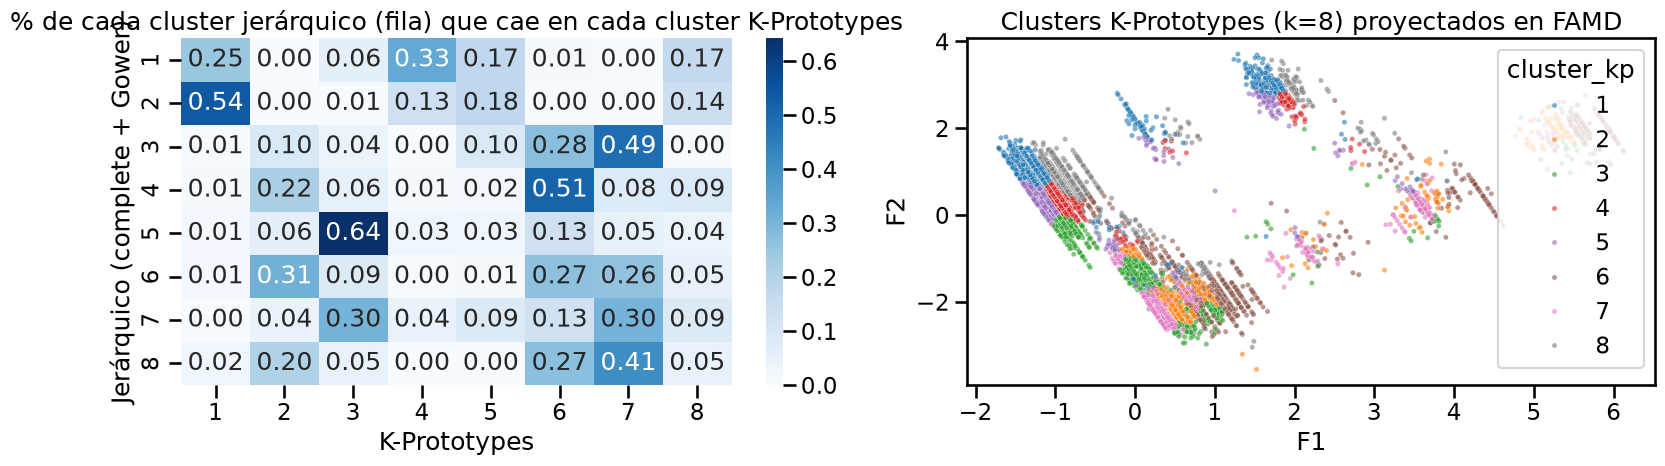

               n     lc   prof  trampas  hembra  huevos  cirr
cluster_kp                                                   
1           1524  90.01  26.71     2.75    0.03    0.02  0.39
2            774  73.31  30.39     2.50    1.00    2.06  0.31
3            931  60.84  26.69     4.00    0.68    0.57  0.08
4           1699  75.32  30.73     1.50    0.02    0.00  0.09
5            990  76.07  21.59     4.90    0.06    0.12  0.24
6            955  71.12  44.49     4.00    0.94    2.56  0.60
7            704  70.45  21.36     2.00    0.99    1.80  0.34
8           1046  85.32  41.48     4.00    0.16    0.38  0.23


In [53]:
df_ind['cluster_kp'] = modelos_kp[K_JER] + 1

cruce = pd.crosstab(df_ind['cluster_jer'], df_ind['cluster_kp'])
print(f"ARI jerárquico vs K-Prototypes (k={K_JER}): {adjusted_rand_score(df_ind['cluster_jer'], df_ind['cluster_kp']):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(cruce.div(cruce.sum(axis=1), axis=0), annot=True, fmt='.2f', cmap='Blues', ax=ax[0])
ax[0].set_title('% de cada cluster jerárquico (fila) que cae en cada cluster K-Prototypes')
ax[0].set_xlabel('K-Prototypes'); ax[0].set_ylabel('Jerárquico (complete + Gower)')

sns.scatterplot(x=coords['F1'], y=coords['F2'], hue=df_ind['cluster_kp'], palette='tab10', s=14, alpha=0.6, ax=ax[1])
ax[1].set_title(f'Clusters K-Prototypes (k={K_JER}) proyectados en FAMD')
plt.tight_layout(); plt.show()

# Qué variables separan los clusters de K-Prototypes
print(df_ind.groupby('cluster_kp').agg(n=('cluster_kp', 'size'), lc=('largo_caparazon', 'mean'), prof=('profundidad', 'mean'),
      trampas=('num_trampas', 'median'), hembra=('sexo', lambda s: (s == 'hembra').mean()),
      huevos=('huevos_ord', 'mean'), cirr=('cirripedio_nivel', 'mean')).round(2))

### Selección de k y lectura de la comparación

- **Elección de k:** con 4  variables categóricas, la silueta sobre Gower es casi plana entre k=3 y k=10 (0,57-0,63), así que no discrimina bien. La tabla anterior marca k=6 como máximo (0,629), pero se fija **k=8** (silueta 0,596): es el menor k en que las hembras pequeñas sin huevos se separan de las ovígeras y los machos con cirripedios de los sanos. Los clusters 7 y 8 son muy chicos (23 y 44 individuos) y se interpretan con cautela.
- **K-Prototypes** coincide en tres estructuras: hembras pequeñas sin huevos (jerárquico 5 ↔ K-Prototypes 3, 64%), hembras profundas con epibiontes (4 ↔ 6, 51%) y machos grandes con cirripedios (2 ↔ 1, 54%). Para el resto reparte distinto: corta el grueso de machos y de hembras ovígeras por **talla y profundidad** (variables continuas estandarizadas), mientras que el jerárquico lo hace por combinaciones de categorías. El ARI global es bajo (0,195).
- La silueta de K-Prototypes medida sobre Gower es baja (≈0,03 con k=8) porque Gower es la métrica que optimiza el jerárquico; no significa por sí sola que sea una mala partición, pero tampoco hay evidencia de que sea mejor.

Se adopta el **jerárquico (complete + Gower, k=8)** para caracterizar: usa una métrica única para todas las variables, sus grupos son interpretables en términos biológicos y k se puede revisar sobre el dendrograma. K-Prototypes queda como contraste, y como alternativa si el dataset creciera a cientos de miles de filas.

## 2.5 Caracterización de los clusters


In [54]:
ORDEN_FECHA = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
ESTACION = {'ene': 'verano', 'abril': 'otoño', 'jul': 'invierno', 'oct': 'primavera'}
df_ind['estacion'] = df_ind['fecha'].str.split('_').str[0].map(ESTACION)
df_ind['anio'] = '19' + df_ind['fecha'].str.split('_').str[1]

# Hembra portando huevos: estadios 1-4 y 6 (5 = cápsulas vacías y 7 = trazas ya no portan puesta)
df_ind['ovigera'] = ((df_ind['sexo'] == 'hembra') & df_ind['huevos_ord'].isin([1, 2, 3, 4, 6])).astype(int)
df_ind['cirripedio_presente'] = (df_ind['cirripedio_nivel'] > 0).astype(int)

def moda(s):
    return s.value_counts().index[0]

perfil = df_ind.groupby('cluster_jer').agg(
    n=('cluster_jer', 'size'),
    LC_media=('largo_caparazon', 'mean'),
    LC_sd=('largo_caparazon', 'std'),
    prof_media=('profundidad', 'mean'),
    trampas_mediana=('num_trampas', 'median'),
    pct_hembra=('sexo', lambda s: (s == 'hembra').mean() * 100),
    pct_ovigera=('ovigera', lambda s: s.mean() * 100),
    huevos_medio=('huevos_ord', 'mean'),
    pct_cirripedio=('cirripedio_presente', lambda s: s.mean() * 100),
    pct_balanus=('estado', lambda s: (s == 'balanus').mean() * 100),
    fecha_modal=('fecha', moda),
)
perfil['pct_total'] = perfil['n'] / perfil['n'].sum() * 100
sector_conocido = df_ind[df_ind['sector_canal'] != 'Sin dato']
perfil['pct_oeste'] = sector_conocido.groupby('cluster_jer')['sector_canal'].apply(lambda s: (s == 'Oeste').mean() * 100)
perfil.round(1)


,n,LC_media,LC_sd,prof_media,trampas_mediana,pct_hembra,pct_ovigera,huevos_medio,pct_cirripedio,pct_balanus,fecha_modal,pct_total,pct_oeste
cluster_jer,,,,,,,,,,,,,
1,4782,79.7,9.5,29.8,2.5,0.0,0.0,0.0,0.0,0.9,oct_98,55.5,18.0
2,542,86.0,6.9,28.0,3.0,0.0,0.0,0.0,100.0,82.3,jul_96,6.3,32.2
3,178,72.3,5.5,31.1,2.0,100.0,100.0,3.0,81.5,100.0,jul_97,2.1,65.6
4,434,73.1,6.3,38.3,4.0,100.0,29.7,3.7,99.5,100.0,ene_96,5.0,15.1
5,660,64.4,8.2,30.0,4.0,100.0,0.0,0.0,0.0,1.1,jul_96,7.7,22.2
6,1960,71.9,6.3,31.5,3.0,100.0,93.5,2.1,0.0,1.8,oct_97,22.7,24.3
7,23,69.2,9.3,28.0,3.0,100.0,69.6,1.0,100.0,0.0,ene_96,0.3,25.0
8,44,71.9,5.7,30.3,2.8,100.0,86.4,2.3,100.0,0.0,oct_97,0.5,29.4


**Perfil de cada cluster** (centollón, n = 8.623)

| Cluster | n (%) | Perfil |
|---|---|---|
| 1 | 4.782 (55%) | **Machos sanos**: sin cirripedios, LC ≈ 80 mm. El grupo modal |
| 2 | 542 (6,3%) | **Machos con cirripedios** (100%) y epibiosis de *Balanus* (82%); LC ≈ 86 mm |
| 3 | 178 (2,1%) | **Hembras ovígeras con huevos con ojos** (estadio 3) y *Balanus* (100%), cirripedios 82%; concentradas en jul_97 |
| 4 | 434 (5,0%) | **Hembras con *Balanus* y cirripedios** (≈ 100%), solo 30% ovígeras; las más profundas (≈ 38 m); modal ene_96 |
| 5 | 660 (7,7%) | **Hembras pequeñas sin huevos**, sin infección (LC ≈ 64 mm; 63% bajo el P25 de su sexo) |
| 6 | 1.960 (23%) | **Hembras ovígeras sin cirripedios** (94% con huevos, estadio medio ≈ 2); LC ≈ 72 mm; modal oct_97 |
| 7 | 23 (0,3%) | Hembras con cirripedios y huevos en estadio 1 |
| 8 | 44 (0,5%) | Hembras con cirripedios (nivel 2) y huevos (86% ovígeras) |

El sexo y el estado reproductivo estructuran los clusters (machos vs. hembras sin huevos vs. ovígeras), y el segundo eje lo marcan las infecciones por cirripedios/*Balanus*. La talla separa solo a las hembras pequeñas sin huevos (cluster 5); la profundidad, al cluster 4. Las diferencias de esfuerzo entre clusters son pequeñas (mediana de 2 a 4 trampas por evento).


sector_canal,Este,Oeste,Sin dato
fecha,,,
ene_96,0,0,861
abril_96,0,0,162
jul_96,1428,188,0
oct_96,1093,162,0
jul_97,758,580,0
oct_97,1785,0,0
oct_98,906,700,0


Cluster x sector (todas las campañas): V de Cramér = 0.186, p = 2.5e-53
Cluster x sector (solo campañas ['jul_96', 'oct_96', 'jul_97', 'oct_98']): V de Cramér = 0.226, p = 4.1e-60


sector_canal,Este,Oeste,total
cluster_jer,,,
1,2847,797,3644
2,259,146,405
3,54,105,159
4,142,43,185
5,336,138,474
6,529,388,917
7,9,3,12
8,9,10,19


Cluster x campaña: V de Cramér = 0.210, p = 0


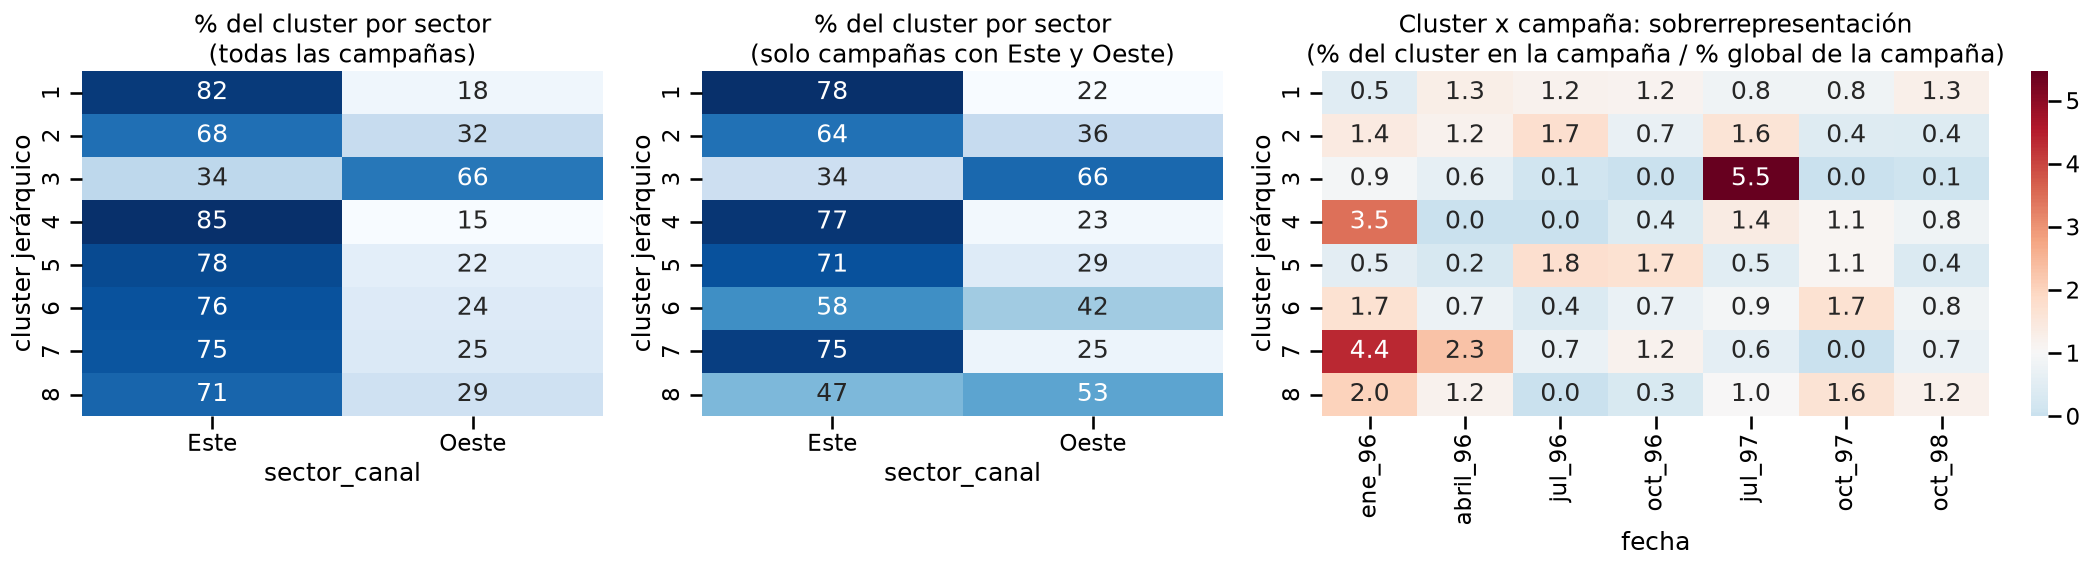

In [55]:
from scipy.stats import chi2_contingency

def cramers_v(tabla):
    chi2, p, _, _ = chi2_contingency(tabla)
    return np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1))), p

# Cobertura de sectores por campaña: Oeste solo se muestreó en 4 de las 7
cobertura = pd.crosstab(df_ind['fecha'], df_ind['sector_canal']).reindex(ORDEN_FECHA)
display(cobertura)

# Cluster x sector (sin 'Sin dato')
con_sector = df_ind[df_ind['sector_canal'] != 'Sin dato']
t_sector = pd.crosstab(con_sector['cluster_jer'], con_sector['sector_canal'])
v, p = cramers_v(t_sector)
print(f'Cluster x sector (todas las campañas): V de Cramér = {v:.3f}, p = {p:.2g}')

# Control por temporada: solo campañas donde se muestrearon ambos sectores
camp_ambas = cobertura[(cobertura['Este'] > 0) & (cobertura['Oeste'] > 0)].index.tolist()
sub = con_sector[con_sector['fecha'].isin(camp_ambas)]
t_sector_ctrl = pd.crosstab(sub['cluster_jer'], sub['sector_canal'])
v2, p2 = cramers_v(t_sector_ctrl)
print(f'Cluster x sector (solo campañas {camp_ambas}): V de Cramér = {v2:.3f}, p = {p2:.2g}')
display(t_sector_ctrl.assign(total=t_sector_ctrl.sum(axis=1)))

# Cluster x fecha
t_fecha = pd.crosstab(df_ind['cluster_jer'], df_ind['fecha'])[ORDEN_FECHA]
v3, p3 = cramers_v(t_fecha)
print(f'Cluster x campaña: V de Cramér = {v3:.3f}, p = {p3:.2g}')

fig, ax = plt.subplots(1, 3, figsize=(22, 6), gridspec_kw={'width_ratios': [1, 1, 1.6]})
sns.heatmap(t_sector.div(t_sector.sum(axis=1), axis=0) * 100, annot=True, fmt='.0f', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('% del cluster por sector\n(todas las campañas)')
sns.heatmap(t_sector_ctrl.div(t_sector_ctrl.sum(axis=1), axis=0) * 100, annot=True, fmt='.0f', cmap='Blues', ax=ax[1], cbar=False)
ax[1].set_title('% del cluster por sector\n(solo campañas con Este y Oeste)')
# Razón respecto de la composición global de cada campaña: >1 = cluster sobrerrepresentado
lift = t_fecha.div(t_fecha.sum(axis=1), axis=0) / (t_fecha.sum(axis=0) / t_fecha.values.sum())
sns.heatmap(lift, annot=True, fmt='.1f', cmap='RdBu_r', center=1, ax=ax[2])
ax[2].set_title('Cluster x campaña: sobrerrepresentación\n(% del cluster en la campaña / % global de la campaña)')
for a in ax: a.set_ylabel('cluster jerárquico')
plt.tight_layout(); plt.show()

**Cruce con sector del canal y temporada**

- **Sector:** en las campañas con ambos sectores muestreados, el Oeste aporta ≈ 28% de los individuos, pero concentra más que su parte de las hembras ovígeras (cluster 3: 66%; cluster 6: 42%) y de los machos con cirripedios (cluster 2: 36%). Los machos sanos (1) y las hembras con epibiontes (4) quedan sub-representados en el Oeste (22-23%). La asociación es débil-moderada (V de Cramér = 0,19 con todas las campañas, 0,23 solo con las que tienen ambos sectores).
- **Temporada:** la asociación cluster × campaña es similar (V = 0,21). El cluster 3 se concentra en jul_97 (×5,5), el 4 en ene_96 (×3,5), el 6 en ene_96 y oct_97 (×1,7), el 5 en jul_96 y oct_96 (×1,7-1,8) y el 2 en jul_96 y jul_97 (×1,6-1,7). Los machos sanos (1) están repartidos de forma pareja, salvo por debajo en ene_96 (×0,5).

**Límites que condicionan la lectura:**

- ene_96 y abr_96 (1.023 individuos) no tienen coordenadas: no se pueden asignar a un sector. Los clusters 4, 7 y 8 se apoyan en buena medida en esas campañas.
- El Oeste solo se muestreó en 4 de las 7 campañas, y sector y campaña no están cruzados de forma balanceada (oct_97 es 100% Este). Parte del efecto "sector" puede ser efecto "campaña": el cluster 3 es a la vez "Oeste" y "jul_97".
- Con n grande, p-valores ínfimos no implican efectos grandes: se reporta V de Cramér.


## 2.6 Clusters de mayor riesgo para el recurso

El "riesgo" de un cluster se define con tres componentes observables, todas expresadas como proporción de individuos del cluster:

1. **Talla chica relativa:** `largo_caparazon` por debajo del percentil 25 de su sexo (evita que "chico" signifique simplemente "hembra").
2. **Hembras ovígeras:** hembras portando huevos (estadios 1-4 y 6).
3. **Esfuerzo alto:** individuos capturados en eventos con más trampas que el percentil 75 del esfuerzo (el esfuerzo no entra al clustering, pero sí a este índice).


Veamos las justificaciones pero el primero lo tomo claramente el temaaño representar individuos que todavía no alcanzaron una talla reproductiva. El segundo igual aunque ya sabemos que en general las hembras son devueltas.

Cada componente se lleva a [0, 1] entre clusters (min-max) y el índice de riesgo es su promedio. También se reporta el volumen (n) de cada cluster: el min-max infla los clusters muy chicos (el 7 tiene 23 individuos), y un riesgo moderado en miles de individuos pesa más que uno alto en decenas.


Esfuerzo alto: > 5 trampas por evento


,n,pct_talla_chica,pct_ovigera,pct_esfuerzo_alto,indice_riesgo,ovigeras_n
cluster_jer,,,,,,
3,178,10.67,100.00,31.46,0.70,178
5,660,62.73,0.00,27.27,0.60,0
7,23,34.78,69.57,21.74,0.58,16
6,1960,16.68,93.52,17.76,0.49,1833
8,44,11.36,86.36,11.36,0.33,38
4,434,10.60,29.72,22.35,0.32,129
2,542,4.06,0.00,28.78,0.29,0
1,4782,27.06,0.00,17.08,0.23,0


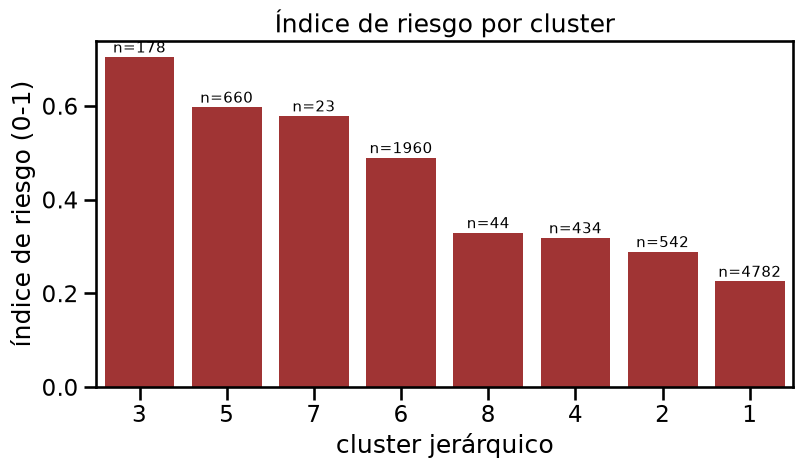

In [56]:
q25 = df_ind.groupby(['especie', 'sexo'])['largo_caparazon'].transform(lambda s: s.quantile(0.25))
df_ind['talla_chica'] = (df_ind['largo_caparazon'] < q25).astype(int)

P75_TRAMPAS = df_ind['num_trampas'].quantile(0.75)
df_ind['esfuerzo_alto'] = (df_ind['num_trampas'] > P75_TRAMPAS).astype(int)
print(f'Esfuerzo alto: > {P75_TRAMPAS:.0f} trampas por evento')

riesgo = df_ind.groupby('cluster_jer').agg(
    n=('cluster_jer', 'size'),
    pct_talla_chica=('talla_chica', lambda s: s.mean() * 100),
    pct_ovigera=('ovigera', lambda s: s.mean() * 100),
    pct_esfuerzo_alto=('esfuerzo_alto', lambda s: s.mean() * 100),
)
comp = riesgo[['pct_talla_chica', 'pct_ovigera', 'pct_esfuerzo_alto']]
riesgo['indice_riesgo'] = ((comp - comp.min()) / (comp.max() - comp.min())).mean(axis=1)
riesgo['ovigeras_n'] = df_ind.groupby('cluster_jer')['ovigera'].sum()
riesgo = riesgo.sort_values('indice_riesgo', ascending=False)
display(riesgo.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=riesgo.index.astype(str), y=riesgo['indice_riesgo'], color='firebrick', ax=ax)
for i, (idx, fila) in enumerate(riesgo.iterrows()):
    ax.text(i, fila['indice_riesgo'] + 0.01, f"n={int(fila['n'])}", ha='center', fontsize=11)
ax.set_xlabel('cluster jerárquico'); ax.set_ylabel('índice de riesgo (0-1)')
ax.set_title('Índice de riesgo por cluster')
plt.show()

Clusters de riesgo alto (índice >= 0,45): [3, 5, 7, 6] -> 2,821 individuos (33%)


,,,n,pct_riesgo,pct_ovigera,pct_talla_chica,trampas_mediana,prof
localizacion,fecha,sector_canal,,,,,,
wp 172,oct_97,Este,208,92.3,76.9,5.8,2.5,40.0
al S de baliza de E. Remolino,jul_97,Oeste,140,76.4,68.6,12.9,2.0,18.0
wp 154,jul_97,Oeste,166,74.1,75.3,6.0,0.8,21.0
wp 236,oct_98,Oeste,160,68.1,61.9,12.5,5.0,28.0
wp 58,oct_96,Este,160,67.5,51.2,35.0,10.0,21.0
S islote Belgrano/punta navarro,ene_96,Sin dato,119,66.4,63.0,0.8,2.0,27.0
wp 57,oct_96,Oeste,162,61.1,6.2,64.2,10.0,34.0
wp 33,jul_96,Este,223,57.8,30.9,53.8,0.8,22.0
wp 165,oct_97,Este,151,55.6,51.0,12.6,2.0,32.0


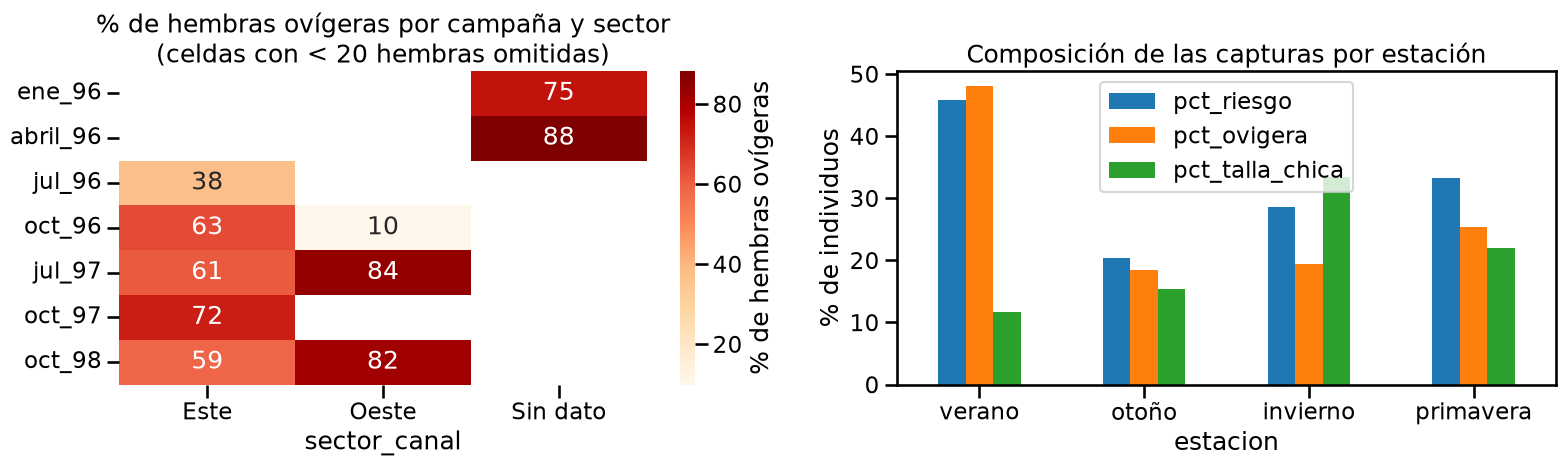

{'verano': 861, 'otoño': 162, 'invierno': 2954, 'primavera': 4646}


In [58]:
# Corte en el salto natural del índice (0,49 -> 0,33); con 0,5 quedaría afuera el cluster 6, que reúne ~84% de las ovígeras
CLUSTERS_RIESGO = riesgo[riesgo['indice_riesgo'] >= 0.45].index.tolist()
df_ind['riesgo_alto'] = df_ind['cluster_jer'].isin(CLUSTERS_RIESGO).astype(int)
print('Clusters de riesgo alto (índice >= 0,45):', CLUSTERS_RIESGO,
      f"-> {df_ind['riesgo_alto'].sum():,} individuos ({df_ind['riesgo_alto'].mean()*100:.0f}%)")

# Eventos localización x campaña con al menos 30 individuos
zonas = df_ind.groupby(['localizacion', 'fecha', 'sector_canal']).agg(
    n=('riesgo_alto', 'size'),
    pct_riesgo=('riesgo_alto', lambda s: s.mean() * 100),
    pct_ovigera=('ovigera', lambda s: s.mean() * 100),
    pct_talla_chica=('talla_chica', lambda s: s.mean() * 100),
    trampas_mediana=('num_trampas', 'median'),
    prof=('profundidad', 'mean'),
).query('n >= 30').sort_values('pct_riesgo', ascending=False)
display(zonas.head(15).round(1))

# Hembras ovígeras: proporción entre las hembras capturadas, por campaña y sector
hembras = df_ind[df_ind['sexo'] == 'hembra']
ovig_camp = hembras.pivot_table(index='fecha', columns='sector_canal', values='ovigera', aggfunc='mean').reindex(ORDEN_FECHA) * 100
n_hembras = hembras.pivot_table(index='fecha', columns='sector_canal', values='ovigera', aggfunc='size').reindex(ORDEN_FECHA)
ovig_camp = ovig_camp.where(n_hembras >= 20)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(ovig_camp, annot=True, fmt='.0f', cmap='OrRd', ax=ax[0], cbar_kws={'label': '% de hembras ovígeras'})
ax[0].set_title('% de hembras ovígeras por campaña y sector\n(celdas con < 20 hembras omitidas)')
ax[0].set_ylabel('')

riesgo_estacion = df_ind.groupby('estacion').agg(pct_riesgo=('riesgo_alto', 'mean'), pct_ovigera=('ovigera', 'mean'),
                                                 pct_talla_chica=('talla_chica', 'mean')) * 100
riesgo_estacion = riesgo_estacion.reindex(['verano', 'otoño', 'invierno', 'primavera'])
riesgo_estacion.plot.bar(ax=ax[1], rot=0)
ax[1].set_title('Composición de las capturas por estación'); ax[1].set_ylabel('% de individuos')
plt.tight_layout(); plt.show()
print(df_ind.groupby('estacion').size().reindex(['verano', 'otoño', 'invierno', 'primavera']).to_dict())


In [59]:
# Localizaciones con coordenadas: % de individuos en clusters de riesgo alto y volumen capturado
mapa_riesgo = (df_ind.dropna(subset=['latitud', 'longitud'])
               .groupby('localizacion')
               .agg(latitud=('latitud', 'median'), longitud=('longitud', 'median'), n=('riesgo_alto', 'size'),
                    pct_riesgo=('riesgo_alto', lambda s: s.mean() * 100),
                    pct_ovigera=('ovigera', lambda s: s.mean() * 100),
                    campañas=('fecha', lambda s: ', '.join(sorted(s.unique())))).reset_index())
mapa_riesgo = mapa_riesgo.query('n >= 30')

fig = px.scatter_map(mapa_riesgo, lat='latitud', lon='longitud', size='n', color='pct_riesgo',
                     color_continuous_scale='YlOrRd', hover_name='localizacion',
                     hover_data={'n': True, 'pct_riesgo': ':.0f', 'pct_ovigera': ':.0f', 'campañas': True,
                                 'latitud': False, 'longitud': False},
                     zoom=8, map_style='open-street-map')
fig.add_scattermap(lat=[-54.9239167], lon=[-67.4822944], mode='markers+text', text=['Paso Mackinlay'],
                   marker=dict(size=14, color='black'), name='Paso Mackinlay')
fig.update_layout(coloraxis_colorbar_title='% individuos<br>en riesgo alto')
fig.show()

## 2.7 Recomendación

**Qué muestran los clusters de mayor riesgo** (índice ≥ 0,45: clusters 3, 5, 7 y 6; 33% de los individuos)

- **Cluster 6 (hembras ovígeras sin cirripedios):** 23% de las capturas y 1.833 de las 2.194 hembras ovígeras (84%). Con índice 0,49 queda justo bajo el 0,5, pero es el grupo que más pesa sobre el reclutamiento por volumen.
- **Cluster 3 (hembras ovígeras con huevos con ojos y *Balanus*):** el de mayor índice (0,70), 100% ovígeras, pero solo 178 individuos, concentrados en jul_97 y en el Oeste (66%).
- **Cluster 5 (hembras pequeñas sin huevos):** 660 individuos con LC ≈ 64 mm, 63% bajo el P25 de su sexo. Son las futuras reproductoras.
- **Cluster 7:** 23 individuos; su índice alto se debe al tamaño del grupo, no se usa para decidir zonas.

**Zonas y épocas a proteger (eventos con mayor proporción de individuos en riesgo alto, n ≥ 30)**

| Prioridad | Zona (localización) | Sector | Campaña | Evidencia |
|---|---|---|---|---|
| 1 | Bloque wp 162-172 (lat ≈ -54,91 a -54,93; lon ≈ -67,06 a -67,21) | Este | oct (1997) | wp 172: 92% en riesgo alto, 77% ovígeras (40 m); wp 162, 164, 165: 49-56% en riesgo alto |
| 2 | S de baliza E. Remolino, wp 154 y wp 236 (lon ≈ -67,60 a -67,88) | Oeste | jul (1997), oct (1998) | 68-76% en riesgo alto; 62-75% ovígeras |
| 3 | wp 58 (Este) y wp 57 (Oeste) | ambos | oct (1996) | 10 trampas de mediana; 61-68% en riesgo alto; en wp 57, 64% de talla chica relativa |
| 4 | wp 33 | Este | jul (1996) | 58% en riesgo alto, 54% de talla chica relativa |

Además, en ene_96 (sin coordenadas) hay eventos con 52-66% de riesgo alto (S islote Belgrano/Punta Navarro, frente bal. Ponsatti, SW islote Belgrano): no se pueden ubicar en un sector, así que se señalan como vacío de información, no como zona segura.

**Medidas propuestas**

1. **Veda de retención de hembras ovígeras en todo el canal**, con devolución obligatoria al agua. Es la medida de mayor impacto: el cluster 6 reúne el 84% de las ovígeras, y la proporción de hembras ovígeras es alta en casi todas las campañas y sectores (38-88%; la excepción es el Oeste en oct 1996, con 10%).
2. **Áreas de veda rotativa** en los bloques de las prioridades 1 y 2, en primavera (oct), que concentra el 54% del muestreo y donde 33% de los individuos están en riesgo alto, y en invierno para el Oeste, donde las ovígeras alcanzaron 84% de las hembras (jul 1997).
3. **Protección de hembras pequeñas:** talla mínima de retención o ventanas de escape en las trampas, sobre todo en invierno, la estación con mayor proporción de ejemplares de talla chica (33%). Tope de trampas por evento en los sitios de prioridad 3, donde se calaron 10 trampas de mediana.
4. **Monitoreo estandarizado:** registrar coordenadas y número de trampas en todos los eventos (el 12% de los individuos no tiene coordenadas), muestrear el Oeste en todas las estaciones y repetir el análisis con datos actuales.

**Limitaciones:** los datos son de 1996-1998 y de pocas campañas; la distribución entre sectores y estaciones no es balanceada; el esfuerzo no fue asignado al azar; el análisis se limita al centollón (la centolla, 244 individuos, queda fuera y requiere un análisis propio); y las zonas listadas son las de mayor riesgo *en los datos*, no un diagnóstico poblacional. Antes de adoptar vedas conviene validar con campañas recientes.


------------------------------------------------------------ otras cuestiones 

1. Riesgo directo por extracción → MACHOS

Acá deberías enfocarte especialmente en:

tamaño de los machos;
proporción de machos pequeños;
distribución de tallas;
concentración espacial/temporal de machos vulnerables;
esfuerzo de captura.

Por ejemplo:

Machos pequeños + alto esfuerzo = grupo prioritario, porque son individuos que potencialmente pueden ser retenidos antes de alcanzar una talla reproductivamente adecuada.

Y sí: el tamaño de los machos dentro de los clusters es algo que deberías mirar explícitamente.

In [ ]:
machos = df_ind[df_ind['sexo'] == 'macho']

riesgo_machos = machos.groupby('cluster_jer').agg(
    n=('cluster_jer', 'size'),
    talla_media=('largo_caparazon', 'mean'),
    talla_mediana=('largo_caparazon', 'median'),
    pct_talla_chica=('talla_chica', 'mean'),
    pct_esfuerzo_alto=('esfuerzo_alto', 'mean')
)

riesgo_machos['pct_talla_chica'] *= 100
riesgo_machos['pct_esfuerzo_alto'] *= 100

display(riesgo_machos.round(2))

¿Qué clusters contienen machos pequeños y bajo qué nivel de esfuerzo son capturados? ¿Dónde y cuándo se están capturando machos pequeños?

In [ ]:
machos = df_ind[df_ind['sexo'] == 'macho']

zonas_machos = machos.groupby(
    ['localizacion', 'fecha', 'sector_canal']
).agg(
    n=('cluster_jer', 'size'),
    talla_mediana=('largo_caparazon', 'median'),
    pct_talla_chica=('talla_chica', 'mean'),
    trampas_mediana=('num_trampas', 'median')
).query('n >= 30')

zonas_machos['pct_talla_chica'] *= 100

zonas_machos = zonas_machos.sort_values(
    'pct_talla_chica',
    ascending=False
)

display(zonas_machos.head(15).round(1))

Dado que la extracción comercial se concentra en machos y las hembras son devueltas al agua, se realizó un análisis específico de la estructura de tallas de los machos dentro de los clusters. Se identificaron como situaciones prioritarias aquellas en las que se combinan una elevada proporción de machos por debajo del percentil 25 de talla y un esfuerzo de captura elevado.

Me fijo mas en lo machos a ver como me da el clustering
